# PHYS3116 Group Assessment

In [1]:
# Import the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, QTable
import plotly.express as px
import scipy.stats as stats
from scipy.optimize import curve_fit

In [2]:
# LaTeX initialisation
# Many LaTeX parameters set to NULL otherwise plots take 84392409432 years to initialise and run

plt.savefig("amr_plot.png", dpi=300, bbox_inches="tight")
plt.rcParams['figure.dpi'] = 150
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

<Figure size 640x480 with 0 Axes>

In [3]:
# Read in data files
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')
krause = pd.read_csv('Krause21.csv')
vandenberg = pd.read_csv('vandenBerg_table2.csv') 
progenitor = pd.read_csv('Progenitor.csv')

---
## Data Info  ⋆｡ﾟ⋆.݁⟡ ݁ﾟ⊹₊݁.ﾟ☾ ﾟ｡⋆.𖥔 ݁˖°.
---
**Harris Part I - Cluster identifications and positions**
- ['RA'], ['DEC'] Right ascention and Declination (epoch J2000)
- ['L'], ['B'] Galactic longitude and latitude (degrees)
- ['R_Sun'] Distance from Sun (kiloparsecs)
- ['R_gc'] Distance from Galactic center (kpc), assuming R_0=8.0 kpc
- ['X'], ['Y'], ['Z'] Galactic distance components X,Y,Z in kiloparsecs, in a Sun-centered coordinate system; X points toward Galactic center, Y in direction of Galactic rotation, Z toward North Galactic Pole
---
**Harris Part II - Metallicities, Integrated magnitudes, colors** 
- ['Fe/H'] Metallicity [Fe/H]
- ['wt'] Weight of mean metallicity; essentially the number of independent [Fe/H] measurements averaged together.
- ['E(B-V)'] Foreground reddening
- ['V_HB'] V magnitude level of the horizontal branch (or RR Lyraes)
- ['(m-M)V'] Apparent visual distance modulus
- ['V_t'] Integrated V magnitude of the cluster
- ['M_V,t'] Absolute visual magnitude (cluster luminosity),  M_V,t = V_t - (m-M)V
- ['U-B'], ['B-V'], ['V-R'], ['V-I'] Integrated color indices (uncorrected for reddening)
- ['spt] Spectral type of the integrated cluster light
- ['ellip'] Projected ellipticity of isophotes, e = 1-(b/a)
---
**Harris Part III - Radial velocities, velocity dispersions, structural parameters** 
- ['v_r'] Heliocentric radial velocity (km/s)
- ['v_r_e'] Observational (internal) uncertainty in radial velocity
- ['v_LSR'] Radial velocity relative to Solar neighborhood LSR
- ['sig_v'] Central velocity dispersion sig_v (km/s)
- ['sig_v_e'] Observational (internal) uncertainty in velocity dispersion
- ['c'] King-model central concentration, c = log(r_t/r_c); a 'c' denotes a core-collapsed cluster
- ['r_c'] Core radius in arcmin
- ['r_h'] Half-light radius in arcmin
- ['mu_V'] Central surface brightness, V magnitudes per square arcsecond
- ['rho_0'] Central luminosity density, log_10(Solar luminosities per cubic parsec)
- ['lg_tc'] Core relaxation time t(r_c), in log_10(years)
- ['lg_th'] Median relaxation time t(r_h), in log_10(years)
---
**Krause**
- ['Mstar'] Stellar mass (Mstar) of the object
- ['rh'] Half-light radius (rh) of the object
- ['C5'] Compactness parameter (C5) of the object
- ['Age'] Age of the object (Gyr)
- ['FeH'] Metallicity [Fe/H]
---
**VandenBerg**
- ['FeH'] Metallicity [Fe/H]
- ['Age'] Age of the object (Gyr)
- ['Age_err'] Age uncertainty
- ['Method']
- ['Figs']
- ['Range']
- ['HBtype']
- ['R_G'] Distance from Galactic center (kpc)
- ['M_V'] Absolute visual magnitude
- ['v_e0'] Central escape velocity
- ['log_sigma_0'] Central logarithmic velocity dispersion
---

In [4]:
# Harris Part 1: make naming consistent
harris_p1.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p1['Object'] = harris_p1['Object'].astype(str) # make sure object column is string type
harris_p1['Object'] = harris_p1['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 2: make naming consistent
harris_p2.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p2['Object'] = harris_p2['Object'].astype(str) # make sure object column is string type
harris_p2['Object'] = harris_p2['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 3: make naming consistent
harris_p3.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p3['Object'] = harris_p3['Object'].astype(str) # make sure object column is string type
harris_p3['Object'] = harris_p3['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Krause: naming already consistent
krause.loc[krause['Object'].str.upper() == 'RUPRECHT106', 'Object'] = 'Rup106' # change Ruprecht106 to Rup106 for consistency
krause.loc[krause['Object'].str.upper() == 'PALOMAR12', 'Object'] = 'Pal12' # change Palomar12 to Pal12 for consistency

# VandenBerg: make naming consistent
vandenberg.rename(columns={'#NGC': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
vandenberg['Object'] = vandenberg['Object'].astype(str) # make sure object column is string type
vandenberg['Object'] = 'NGC' + vandenberg['Object'] # add NGC to the start of each object
vandenberg.loc[vandenberg['Object'].str.upper() == 'NGCXXXX', 'Object'] = vandenberg.loc[vandenberg['Object'].str.upper() == 'NGCXXXX', 'Name'].astype(str) # change NGCXXXX to the Name column for those objects
vandenberg.loc[vandenberg['Object'].str.upper() == 'TER8', 'Object'] = 'Terzan8' # change Ter8 to Terzan8 for consistency


In [5]:
# number of globular clusters in each data set
print("Harris Part I:", len(harris_p1))
print("Harris Part III:", len(harris_p3))
print("Krause:", len(krause))
print("VandenBerg:", len(vandenberg))

# globular cluster overlaps between data sets
print("Harris 1 and Harris 3:", len(set(harris_p1['Object']) & set(harris_p3['Object'])))
print("Harris 1 and Krause:", len(set(harris_p1['Object']) & set(krause['Object'])))
print("Harris 1 and VandenBerg:", len(set(harris_p1['Object']) & set(vandenberg['Object'])))
print("Krause and VandenBerg:", len(set(krause['Object']) & set(vandenberg['Object'])))
print("All three:", len(set(harris_p1['Object']) & set(krause['Object']) & set(vandenberg['Object'])))

Harris Part I: 157
Harris Part III: 157
Krause: 61
VandenBerg: 55
Harris 1 and Harris 3: 157
Harris 1 and Krause: 61
Harris 1 and VandenBerg: 54
Krause and VandenBerg: 52
All three: 52


In [6]:
# merge data frames
merged_all = pd.merge(harris_p1, harris_p3, on='Object')
merged_all = pd.merge(merged_all, vandenberg, on='Object')
merged_all = pd.merge(merged_all, krause, on='Object')

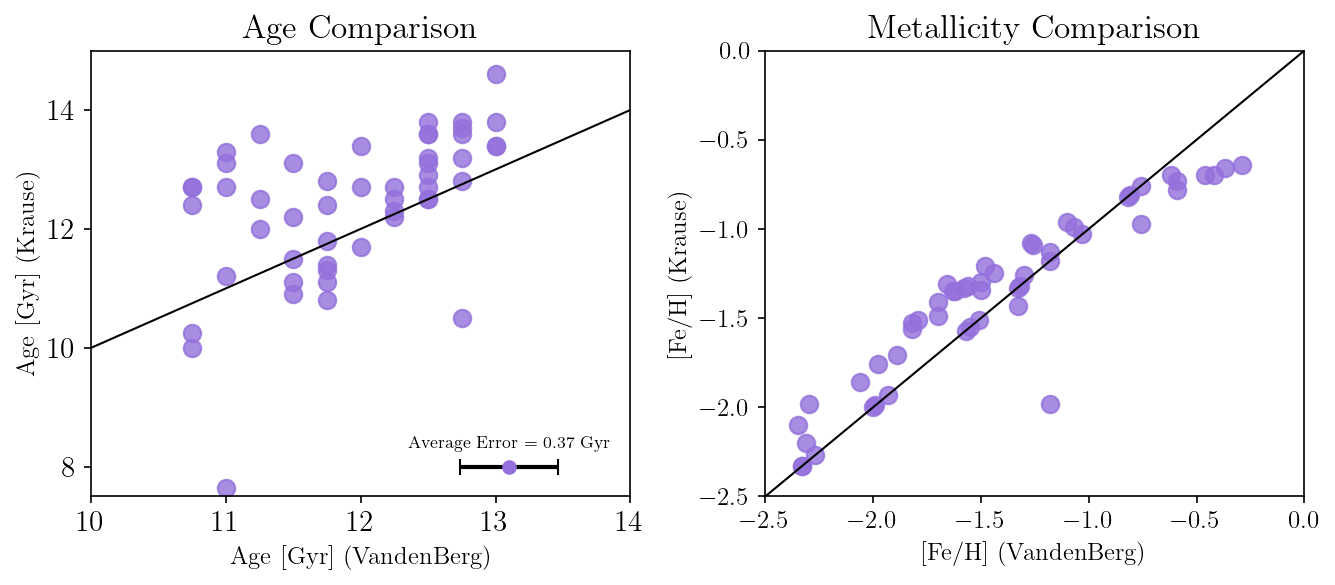

In [7]:
# Plotting comparisons between VandenBerg and Krause data
fig, axes = plt.subplots(1, 2, figsize=(9, 4))  # 1 row, 2 columns

# Age comparison
axes[0].scatter(merged_all['Age_x'], merged_all['Age_y'], color='mediumpurple', s=70, alpha=0.8)
axes[0].plot([10, 15], [10, 15], c='black', linestyle='-', lw=1, label='1:1 Line') # Add 1:1 line

# add a representative error bar in corner
errorbar = merged_all['Age_err'].mean()  # average error
axes[0].errorbar(13.1, 8, xerr=errorbar, marker='o', color='mediumpurple', ecolor='k', capsize=4, lw=2)
axes[0].text(13.1, 8.3, f'Average Error = {errorbar:.2f} Gyr', fontsize=8, ha='center') # error bar text

axes[0].set_xlabel('Age [Gyr] (VandenBerg)', fontsize=12)
axes[0].set_ylabel('Age [Gyr] (Krause)', fontsize=12)
axes[0].set_xlim(10, 14)
axes[0].set_ylim(7.5, 15)
axes[0].set_title('Age Comparison', fontsize=16)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# [Fe/H] comparison
axes[1].scatter(merged_all['FeH_x'], merged_all['FeH_y'], color='mediumpurple', s=70, alpha=0.8)
axes[1].plot([-2.5, 0], [-2.5, 0], c='k', linestyle='-', lw=1, label='1:1 Line') # Add 1:1 line
axes[1].set_xlabel('[Fe/H] (VandenBerg)', fontsize=12)
axes[1].set_ylabel('[Fe/H] (Krause)', fontsize=12)
axes[1].set_xlim(-2.5, 0)
axes[1].set_ylim(-2.5, 0)
axes[1].set_title('Metallicity Comparison', fontsize=16)
axes[1].tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()


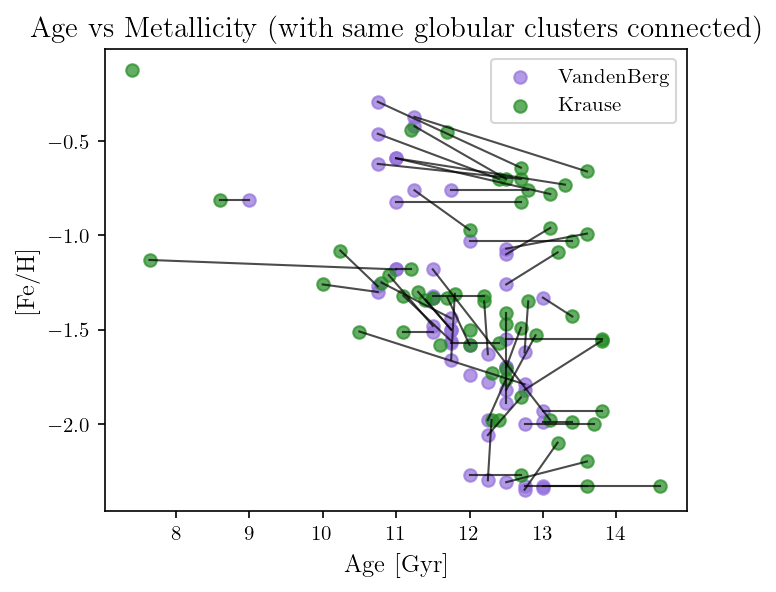

In [8]:
# Age-metallicity plot with data from VandenBerg and Krause with lines connecting matching objects
plt.figure(figsize=(5, 4))
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='mediumpurple', label='VandenBerg', alpha=0.7)
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='forestgreen', label='Krause', alpha=0.7)

# Connect matching objects
for object in set(vandenberg['Object']).intersection(krause['Object']): # find common objects
    v = vandenberg[vandenberg['Object'] == object].iloc[0] # get object row for vandenberg
    k = krause[krause['Object'] == object].iloc[0]  # get object row for krause
    plt.plot([v['Age'], k['Age']], [v['FeH'], k['FeH']],color='k', linestyle='-', linewidth=1, alpha=0.7) # plot line between same objects

# labels
plt.title('Age vs Metallicity (with same globular clusters connected)', fontsize=14)
plt.xlabel('Age [Gyr]', fontsize=12)
plt.ylabel('[Fe/H]', fontsize=12)
plt.legend()
plt.show()

In [9]:
# keep only the vandenberg (x) values for FeH, Age, and R_gc
merged_all['FeH'] = merged_all['FeH_x']
merged_all['Age'] = merged_all['Age_x']
merged_all['r_gc'] = merged_all['R_gc'] # The Galactocentric radius from Harris and VandenBerg have the same values

# drop the unusable columns
merged_all = merged_all.drop(columns=['FeH_x', 'FeH_y', 'Age_x', 'Age_y', 'R_gc', 'R_G'])

## Identifying Clusters with Dynamical Data

In [10]:
# Extracting key spatial coordinates
R = harris_p1["R_gc"]
X = harris_p1["X"]
Y = harris_p1["Y"]
Z = harris_p1["Z"]
names = harris_p1["Object"]

ages_v = vandenberg["Age"]
feh_v  = vandenberg["FeH"]

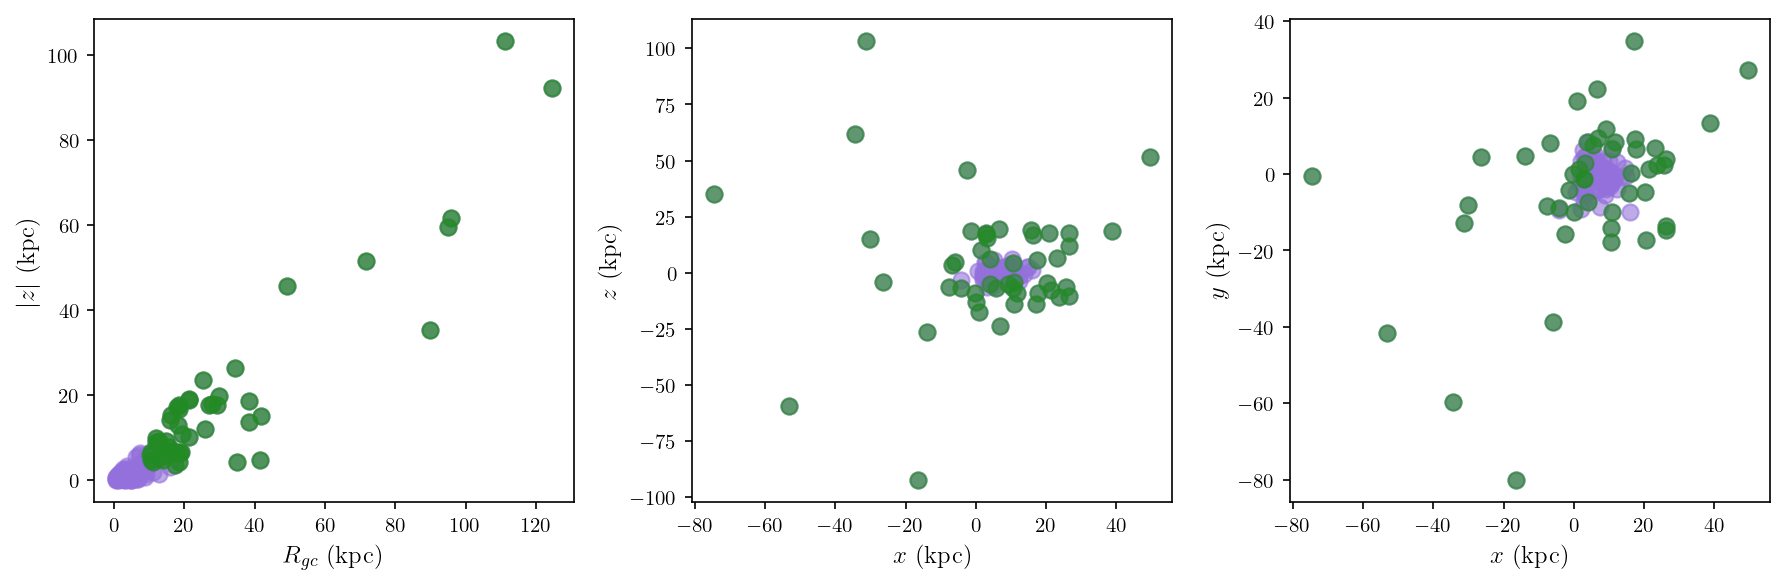

In [11]:
# Identification of accreted clusters
mask = (R > 10) & (abs(Z) > 3)
accreted = harris_p1[mask]
#print("Accreted clusters (R_gc > 10 and |Z| > 3):")
#print(accreted[["ID", "R_gc", "Z"]])

# Create subplots, same code as above
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# R vs |Z|
axes[0].scatter(R, abs(Z), c='mediumpurple', alpha=0.6, s=60)
axes[0].scatter(accreted["R_gc"], abs(accreted["Z"]), c='forestgreen', alpha=0.7, s=60)
axes[0].set_xlabel(r"$R_{gc}$ (kpc)", fontsize=12)
axes[0].set_ylabel(r"$|z|$ (kpc)", fontsize=12)

# X vs Z
axes[1].scatter(X, Z, c='mediumpurple', alpha=0.6, s=60)
axes[1].scatter(accreted["X"], accreted["Z"], c='forestgreen', alpha=0.6, s=60)
axes[1].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[1].set_ylabel(r"$z$ (kpc)", fontsize=12)

# X vs Y
axes[2].scatter(X, Y, c='mediumpurple', alpha=0.6, s=60)
axes[2].scatter(accreted["X"], accreted["Y"], c='forestgreen', alpha=0.6, s=60)
axes[2].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[2].set_ylabel(r"$y$ (kpc)", fontsize=12)

plt.tight_layout()
plt.show()

## Age-metallicity Relation

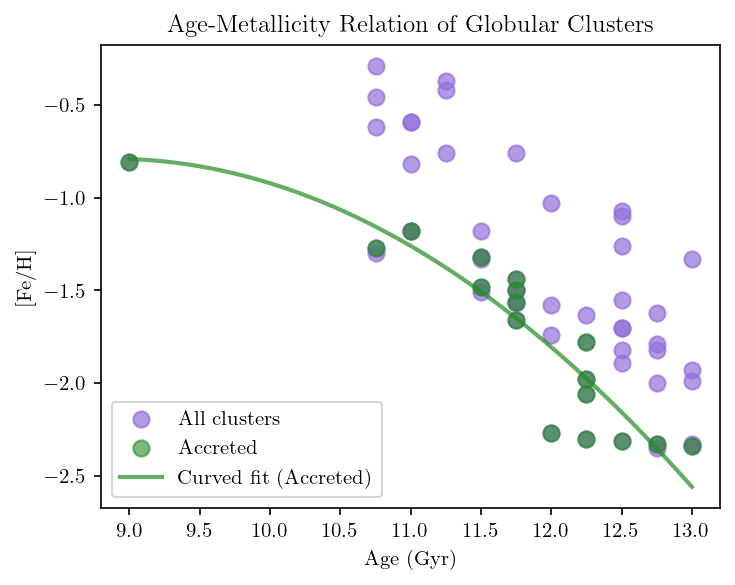

In [12]:
# Identify accreted clusters
mask = (harris_p1["R_gc"] > 10) & (abs(harris_p1["Z"]) > 3)
accreted_names = harris_p1.loc[mask, "Object"]

# Find those names vandenBerg dataset
vberg_mask  = vandenberg["Object"].isin(accreted_names)

# Search through age-metallicity data for clusters that were identified as accreted above
feh_acc = feh_v[vberg_mask]
ages_acc = ages_v[vberg_mask]

# Defined polynomial fit
coeffs = np.polyfit(ages_acc, feh_acc, 2)
a, b, c = coeffs

# Curve fitting
x_fit = np.linspace(min(ages_acc), max(ages_acc), 200)  # Age range
y_fit = a * x_fit**2 + b * x_fit + c                   # [Fe/H] fit

# Plot
plt.figure(figsize=(5,4))

# All clusters (no longer including Krause21)
plt.scatter(ages_v, feh_v, c='mediumpurple', alpha=0.7, s=60, label="All clusters")

# Accreted clusters
plt.scatter(ages_acc, feh_acc, c='forestgreen', alpha=0.6, s=60, label="Accreted")

# # label points with object names
# for i, txt in enumerate(vandenberg['Object']):
#     plt.annotate(txt, (vandenberg['Age'][i], vandenberg['FeH'][i]), fontsize=8, alpha=0.7)

# Curved best-fit line
plt.plot(x_fit, y_fit, color='forestgreen', alpha=0.7, linewidth=2, label="Curved fit (Accreted)")

plt.xlabel("Age (Gyr)")
plt.ylabel("[Fe/H]")
plt.title("Age-Metallicity Relation of Globular Clusters")
plt.legend()
plt.tight_layout()
plt.show()

- Dwarf galaxies are the main sources of accreted globular clusters in the Milky Way.

- Their low metallicity arises from supernova-driven gas loss, as shallow gravitational potentials allow enriched material to escape easily.

- The curved age–metallicity relation (AMR) in Figure 1 reflects gradual chemical enrichment: later generations form from gas increasingly enriched in heavy elements.

- In-situ clusters formed within the Milky Way show systematically higher 
[Fe/H]
[Fe/H] at similar ages due to stronger gravitational retention of metals and more efficient star formation.

- Both accreted and in-situ populations follow the same physical trend of increasing 
[Fe/H] with time, but differ in enrichment rate and metallicity scale because of their distinct formation environments.

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:3710: RuntimeWarning: invalid value encountered in divide
  return sin(y)/y


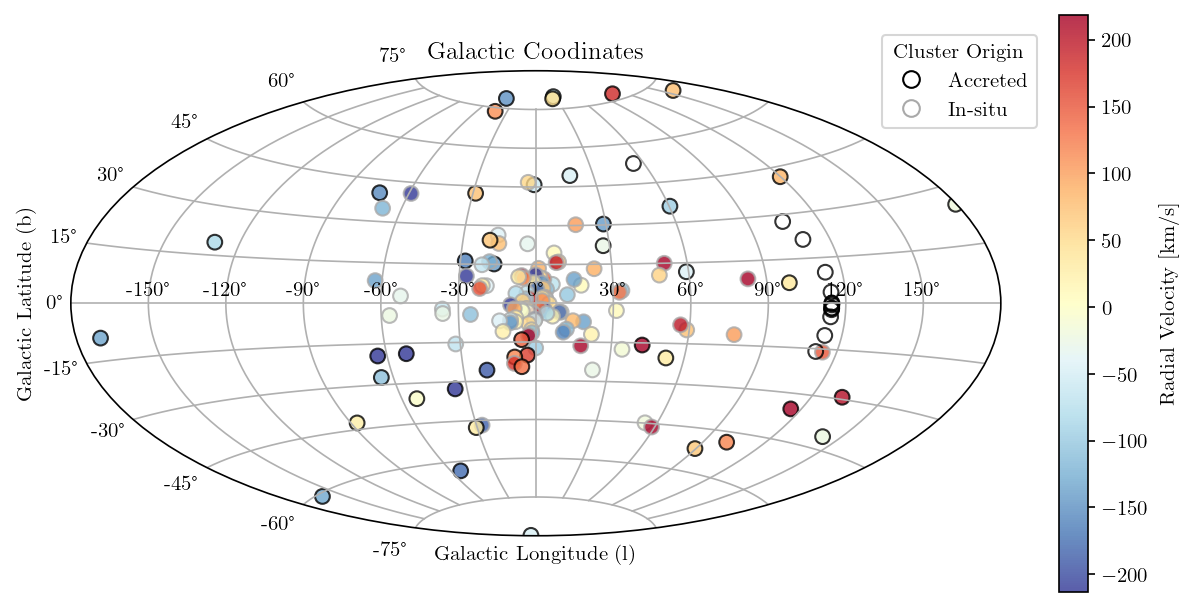

In [13]:
# plot sky distribution of GCs in Galactic coordinates 

# Identify accreted clusters
harris_acc = (harris_p1["R_gc"] > 10) & (abs(harris_p1["Z"]) > 3)
accreted_names = harris_p1.loc[harris_acc, "Object"]
harris_accreted = harris_p1["Object"].isin(accreted_names) # mask for plotting accreted clusters

harris_p1['L'] = pd.to_numeric(harris_p1['L'], errors='coerce')
harris_p1['B'] = pd.to_numeric(harris_p1['B'], errors='coerce')
harris_p3['v_r'] = pd.to_numeric(harris_p3['v_r'], errors='coerce')

# Convert coordinates
l = Angle(harris_p1['L'].to_numpy(), unit='deg')
b = Angle(harris_p1['B'].to_numpy(), unit='deg')
rv = harris_p3['v_r'].to_numpy()  # Radial Velocity

# plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

# edge colors for accreted and in situ
edge_colors = np.where(harris_accreted, 'k', 'darkgray')  # black = accreted, grey = in-situ

# Main scatter plot
sc = ax.scatter(-l.wrap_at('180d').radian, b.radian, s=50, c=rv, cmap='RdYlBu_r', 
    vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95), marker='o', alpha=0.8, ec=edge_colors, lw=1)

# colorbar and labels
plt.colorbar(sc, ax=ax, label='Radial Velocity [km/s]')
# legend for edge colors
legend_handles = [
    plt.Line2D([], [], marker='o', color='w', markeredgecolor='k', markersize=8, label='Accreted'),
    plt.Line2D([], [], marker='o', color='w', markeredgecolor='darkgray', markersize=8, label='In-situ')
]
ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.05, 1.1), frameon=True, title='Cluster Origin')
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("Galactic Coodinates")

ax.grid()
plt.show()

# Figure displays GCs in Galactic coordinates with the centre of the Galaxy at the origin
# blue is blue shifted (moving towards us)
# red is red shifted (moving away from us)


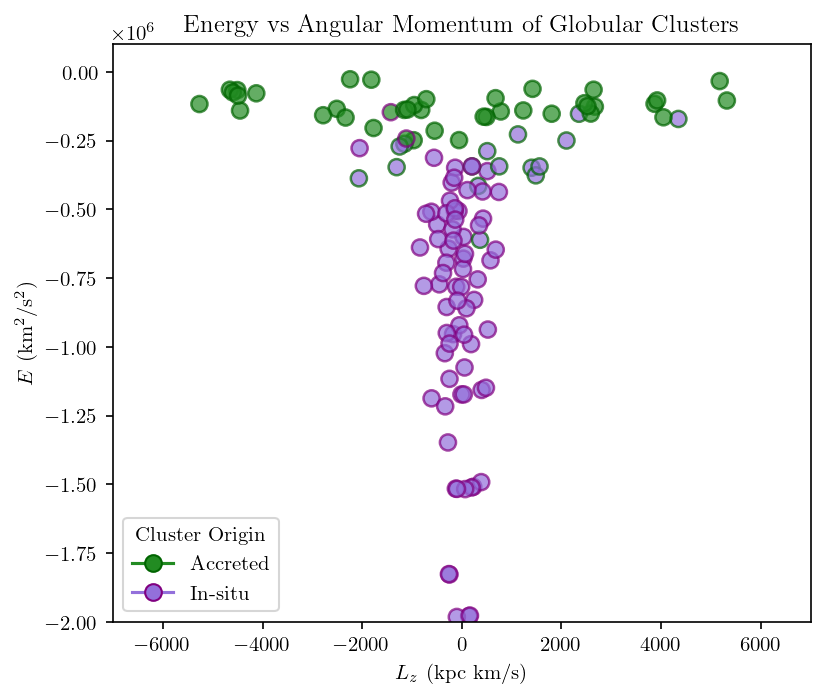

In [ ]:
progenitor = pd.read_csv('Progenitor.csv')

# Energy vs Angular Momentum
merged_harris = pd.merge(harris_p1, harris_p3, on='Object')
merged_harris = pd.merge(merged_harris, progenitor, on='Object')

# Constants (assuming certain values for the Galaxy)
G = 4.30091e-6  # Gravitational constant in kpc (km/s)^2 / Msun
M_gal = 6e11    # Approximate mass of the Milky Way in solar masses

# Calculate total energy (approximate)
merged_harris['E'] = -G * M_gal / merged_harris['R_gc'] + 0.5 * merged_harris['v_r']**2
# Calculate z-component of angular momentum (approximate)
merged_harris['Lz'] = merged_harris['R_gc'] * merged_harris['v_r'] #very approximate (no mass)

# Identify accreted clusters
mask = (harris_p1["R_gc"] > 10) & (abs(harris_p1["Z"]) > 3)
accreted_names = harris_p1.loc[mask, "Object"]

# face colour from previously defined accretion
merged_harris['facecolor'] = np.where(merged_harris['Object'].isin(accreted_names),'forestgreen','mediumpurple')

# Edge colors based on conclusions from papers
edge_colors = merged_harris['Progenitor'].map({'IS': 'purple', 'AC': 'darkgreen'})

# legend handles
legend_handles = [
    plt.Line2D([], [], marker='o', color='forestgreen', markeredgecolor='darkgreen', markersize=8, label='Accreted'),
    plt.Line2D([], [], marker='o', color='mediumpurple', markeredgecolor='purple', markersize=8, label='In-situ')
]

# Plot E vs Lz
plt.figure(figsize=(6, 5))
plt.scatter(merged_harris['Lz'], merged_harris['E'], c=merged_harris['facecolor'], s=60, alpha=0.7, ec=edge_colors, lw=1.2)
plt.xlabel(r'$L_z$ (kpc km/s)')
plt.ylabel(r'$E$ (km$^2$/s$^2$)')
plt.title('Energy vs Angular Momentum of Globular Clusters')
plt.ylim(-2e6, 0.1e6)
plt.xlim(-7000, 7000)
plt.legend(handles=legend_handles, loc='best', title='Cluster Origin')
plt.show()
